# ПРОЕКТ: КЛАССИФИКАЦИЯ КОММЕНТАРИЕВ

## Краткий план работы

| **№ п/п** | **Задача** | **Срок выполнения** |
| :---: | :--- | :---: |
|1.|Импортировать необходимые библиотеки. Загрузить данные. Провести их осмотр.|05.02.2025|
|2.|Провести предобработку данных.|06.02.2025|
|3.|Провести исследовательский анализ.|07.02.2025|
|4.|Разделить датасет на обучающую, тестовую и валидационную выборки.|10.02.2025|
|5.|Обучить модель логистической регресиии с использованием __TF-IDF__. Оценить качество модели по метрике *F1* на валидационной выборке.|11.02.2025|
|6.|Обучить модель логистической регресиии с использованием __spaCy__ эмбеддингов. Оценить качество модели по метрике *F1* на валидационной выборке.|12.02.2025|
|7.|Обучить модель логистической регресиии с использованием ембеддингов __BERT__. Оценить качество модели по метрике *F1* на валидационной выборке.|13.02.2025|
|8.|Получить прогнозы на предобученной модели __BERT (unitary/toxic-bert)__. Оценить качество модели по метрике *F1* на валидационной выборке.|14.02.2025|
|9.|Отобрать лучшую модель по результатам валидации и оценить ее качество на тестовой выборке по метрикам *F1*, *Precision*, *Recall*. Проанализировать *матрицу ошибок* на предмет соответствия задачам бизнеса.|14.02.2025|
|10.|Сформулировать выводы.|17.02.2025|

## Импорт библиотек, определение констант и некоторых переиспользуемых функций. Загрузка моделей

In [1]:
# установка предобученых моделей spacy
!python -m spacy download en_core_web_sm --quiet # для лемматизации
!python -m spacy download en_core_web_lg --quiet # для получения эмбеддингов

/Users/sergey/Documents/Portfolio/TextProcessing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
/Users/sergey/Documents/Portfolio/TextProcessing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [2]:
# основные библиотеки
import os
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re

# функции для работы с метриками оценки качества
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import precision_recall_curve

# инструменты для подготовки данных
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# линейная модель для классификации
from sklearn.linear_model import LogisticRegression

# классы для создания кастомных трасформеров
from sklearn.base import BaseEstimator, TransformerMixin

# классы для создания BERT моделей
from transformers import BertModel, BertTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# инструменты для работы с дисбалансом классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# для батчевой обработки данных
from torch.utils.data import DataLoader, Dataset

# для красивых прогресс-баров
from tqdm import tqdm

# стиль графиков и палитра цветов
sns.set_theme(style='whitegrid')
palette = ['lightgray', 'darkred']

TEST_SIZE = 0.2 # размер тестовой выборки 
RANDOM_STATE = 42 # константа для фиксации воспроизводимости
TOXIC_PROBABILITY_THRESHOLD = 0.5 # порог вероятности принадлежности к положительному классу
LR_MAX_ITER=5000 # максимальное число итераций для обучения логистической регрессии
BATCH_SIZE = 64 # размер батча
CV_N_SPLITS = 5 # количество фолдов для кросс-валидации

# названия предобученных моделей BERT
BERT_MODEL_NAME = 'bert-base-uncased'
UNITARY_TOXIC_BERT = 'unitary/toxic-bert'

# фиксация генераторов случайных чисел для воспроизводимости
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

/Users/sergey/Documents/Portfolio/TextProcessing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Функция для инициализаци датасета

In [3]:
# функция принимает в качестве аргументов локальный путь и сетевой путь
def fetch_data(local_path, url):
    
    # проверяет существует ли локальный файл csv
    if os.path.exists(local_path):
        # если да, то загружает локально
        data = pd.read_csv(local_path)
        # если нет, загружает файл из сети с выводом соответствующего уведомления
    else:
        print('Local file', local_path, 'does not exist.\nDownloading from', url)
        data = pd.read_csv(url) # функция возвращает объект <DataFrame>
    return data

### Функция для очистки текстовых данных

In [4]:
def clean_text(text):
    # удаляем HTML-теги
    result = re.sub(r'<.*?>', ' ', text)
    # удаляем переводы строк и лишние пробелы
    result = re.sub(r'\s+', ' ', text).strip()
    return result # возвращаем очищенный текст

### Функция для построения матрицы ошибок

In [5]:
def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='flare_r')
    ax.set_title(
        'Матрица ошибок',
        fontsize=14,
        fontweight='bold'
    )
    plt.ylabel('True label')
    plt.xlabel('Predicted')
    plt.show()

### Функция для отображения количества дубликатов

In [6]:
def display_duplicates_rate(df):
    count = df.duplicated().sum()
    rate = count / len(df)
    print(f'Явных дубликатов: {count} ({rate:.1%})')

### Функция для отображения круговой диаграммы 

In [7]:
def print_pie(data, startangle=0):
    # стиль и размер
    plt.style.use('seaborn-v0_8-notebook')
    plt.figure(figsize=(8, 8))

    # определяем функцию для возврата процентов
    # для подписей на круговой диаграмме
    def get_percent_with_count(percent, allvals):
        absolute = int(np.round(percent/100.*np.sum(allvals)))
        return f"{percent:.1f}%\n({absolute:d} комментариев)"
    
    plt.pie(
        # передаем количественное распределение меток
        data.value_counts(),
        # устанавливаем подписи к данным
        autopct=lambda percent: get_percent_with_count(percent, data.value_counts()),
        # устанавливаем угол поворота
        startangle=startangle,
        # устанавливаем цвета для категорий
        colors=palette,
        pctdistance=1.4
    )
    
    # устанавливаем название графика
    plt.title(
        'Круговая диаграмма распределения целевой переменной',
        fontsize=14,
        fontweight='bold'
    )
    
    # отображаем легенду
    labels = ['Не токсичный', 'Токсичный']
    plt.legend(labels, title = 'Оттенок комментария', loc='upper right')
    plt.tight_layout()
    plt.show()
    pass

### Функция для инициализации устройства для torch

In [8]:
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device('mps') # для чипов Apple Silicon
    elif torch.cuda.is_available():
        device = torch.device('cuda') # для видеокарты
    else:
        device = torch.device('cpu') # ЦП
    return device

## Загрузка, подготовка и анализ данных

### Загрузка данных

In [9]:
# локальный путь к файлу данных
comments_local = './toxic_comments.csv'

In [10]:
# удаленный адрес для скачивания файла данных
comments_url = 'https://code.s3.yandex.net/datasets/toxic_comments.csv'

In [11]:
# инициализация датасета
comments = fetch_data(comments_local, comments_url)

### Осмотр данных

In [12]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


In [13]:
comments.sample(5)

,Unnamed: 0,text,toxic
31015,31055,"Sometime back, I just happened to log on to ww...",0
102832,102929,"""\n\nThe latest edit is much better, don't mak...",0
67317,67385,""" October 2007 (UTC)\n\nI would think you'd be...",0
81091,81167,Thanks for the tip on the currency translation...,0
90091,90182,I would argue that if content on the Con in co...,0


Данные соответствуют описанию. Столбец `Unnamed: 0` здесь лишний. Тексты нужно чистить от лишних символов.

In [14]:
# удаление столбца 'Unnamed: 0'
comments = comments.drop('Unnamed: 0', axis=1)

### Проверка дубликатов

In [15]:
# дубликаты
display_duplicates_rate(comments)

Явных дубликатов: 0 (0.0%)


Дубликатов в данных нет.

### Анализ распределения целевой переменной

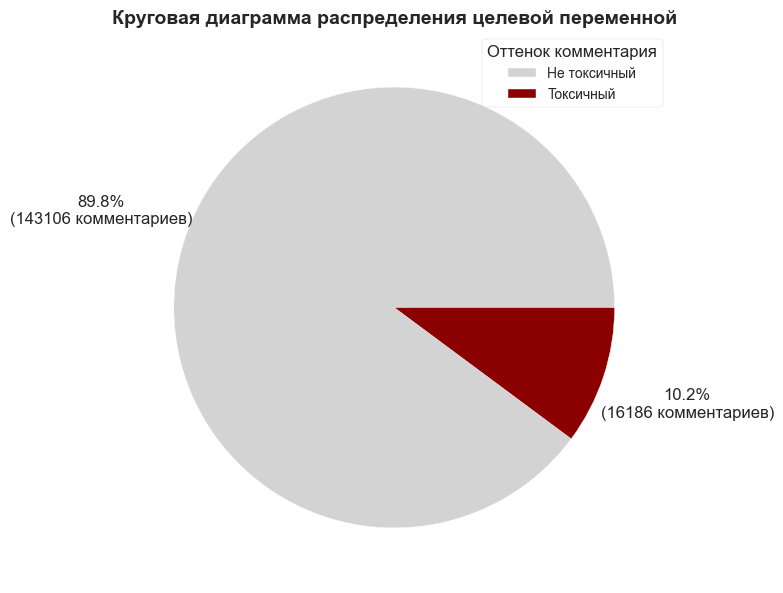

In [16]:
print_pie(comments['toxic'])

Целевая переменная несбалансирована. Необходимо будет использовать инструменты для борьбы с дисбалансом классов.

### Деление выборки на обучающую, валидационную и тестовую

In [17]:
text_train, text_test, label_train, label_test = train_test_split(
    comments[['text']],
    comments['toxic'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=comments['toxic']
)

In [18]:
text_train, text_valid, label_train, label_valid = train_test_split(
    text_train,
    label_train,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=label_train
)

In [19]:
print('Тренировочная выборка')
print(f'Размерность text: {text_train.shape}, размерность label: {label_train.shape[0]}')
print('--------------------------------------------------------')
print('Валидационная выборка')
print(f'Размерность text: {text_valid.shape}, размерность label: {text_valid.shape[0]}')
print('--------------------------------------------------------')
print('Тестовая выборка')
print(f'Размерность text: {text_test.shape}, размерность label: {text_test.shape[0]}')
print('--------------------------------------------------------')

Тренировочная выборка
Размерность text: (101946, 1), размерность label: 101946
--------------------------------------------------------
Валидационная выборка
Размерность text: (25487, 1), размерность label: 25487
--------------------------------------------------------
Тестовая выборка
Размерность text: (31859, 1), размерность label: 31859
--------------------------------------------------------


## LogisticRegression with TF-IDF

In [20]:
# для оптимизации инициализируем список задач spaCy,
# которые не нужны ('parser', 'ner')
disabled_pipes = [
    #'tok2vec', # преобразует текст в векторное представление на основе токенов
    #'tagger', # отвечает за определение части речи 
    'parser', # анализ синтаксиса
    #'attribute_ruler', 
    #'lemmatizer', # отвечает за приведение слов к их базовой форме (лемме)
    'ner' # для распознавания именованных сущностей
]

In [21]:
# инициализируем предобученную модель spaCy для лемматизации
nlp_sm = spacy.load('en_core_web_sm', disable=disabled_pipes)

Определим функции для подготовки текстов - очистка и лемматизация для применения их в цепочках `df.pipe()`.

In [22]:
# функция для очистки текста
def clear_text(df):
    cleared = df['text'].apply(lambda x: re.sub(r"[^a-zA-Z0-9'!?,. ]", ' ', x))
    return df.assign(text=cleared)

In [23]:
# функция для лемматизации текстов
def lemmatize_text(df):
    lemm_texts_result = []
    for doc in tqdm(
        iterable=nlp_sm.pipe(df['text'], disable=disabled_pipes),
        desc='Lemmatizing...', colour='red',
        total=len(df)
    ):
        lemm_text = ' '.join([word.lemma_.lower() for word in doc])  
        lemm_texts_result.append(lemm_text)
    return df.assign(text=lemm_texts_result)

In [24]:
# инициализируем пайплайн
tf_idf_pipeline = Pipeline(
    steps=[
        
        # векторизация
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('tf_idf', TfidfVectorizer(), 'text')
            ],
            remainder='passthrough'
        )),
        # классификация
        ('classifier', LogisticRegression(
            class_weight='balanced', # балансируем целевую переменную
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [25]:
# словарь гиперпараметров
param_grid={
    'classifier__C': range(3, 6),
    # нижний порог количества текстов, в которых встречается слово, для включения его в словарь
    'preprocessor__tf_idf__min_df': [1, 5],
    # верхний порог количества текстов, в которых встречается слово, для включения его в словарь
    'preprocessor__tf_idf__max_df': [0.4, 0.45, 0.6, 0.7]
}

In [26]:
# инициализация объекта GridSearchCV
tf_idf_grid = GridSearchCV(
    tf_idf_pipeline,
    # словарь для модели LogisticRegression()
    param_grid=param_grid,
    # используем валидационную выборку
    cv=KFold(n_splits=CV_N_SPLITS), # кросс-валидация на 5 фолдов
    scoring='f1',
    n_jobs=-1
)

In [27]:
# запускаем поиск гиперпараметров
tf_idf_grid.fit(
    X=(text_train
       .pipe(clear_text) # очистка
       .pipe(lemmatize_text)), # лемматизация
    y=label_train
)

Lemmatizing...: 100%|██████████| 101946/101946 [07:06<00:00, 239.17it/s]


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('tf_idf',
                                                                         TfidfVectorizer(),
                                                                         'text')])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           n_jobs=-1,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': range(3, 6),
                         'preprocessor__tf_idf__max_df': [0.4, 0.45, 0.6, 0.7],
                         'preprocessor__tf_idf__min_df': [1, 5]},
             scoring='f1')

In [28]:
# получаем прогнозы на валидационной выборке
tf_idf_predictions = tf_idf_grid.predict(
    (text_valid
       .pipe(clear_text) # очистка
       .pipe(lemmatize_text)), # лемматизация
)

Lemmatizing...: 100%|██████████| 25487/25487 [01:46<00:00, 239.55it/s]


In [29]:
tf_idf_f1 = f1_score(label_valid, tf_idf_predictions)

## LogisticRegression with spaCy embeddings

In [30]:
# инициализируем модель для получения ембеддингов
nlp_lg = spacy.load('en_core_web_lg')

In [31]:
# функция для получения эмбеддингов
# принимает dataframe c колонкой text
def vectorize(df):
    # для красивого прогресса
    embeddings = [] # список для хранения эмбеддингов
    for doc in tqdm(
        iterable=nlp_lg.pipe(df['text']),
        desc='Vectorizing...', colour='red',
        total=len(df)
    ):
        embeddings.append(doc.vector)

    embeddings_df = pd.DataFrame(
        data=embeddings,
        columns=[f'emb_{i}' for i in range(len(embeddings[0]))],
        index=df.index
    )
    # возвращает исходный dataframe
    # где вместо колонки text будут эмбеддинги
    return embeddings_df.assign(**df).drop('text', axis=1)

In [32]:
# пайплайн
spacy_embs_pipeline = Pipeline(
    steps=[
        # классификатор
        ('classifier', LogisticRegression(
            C=3,
            class_weight='balanced', # балансировка классов
            random_state=RANDOM_STATE,
            max_iter=LR_MAX_ITER,
            n_jobs=-1
        ))
    ]
)

Для поиска лучших гиперпараметров будем использовать кросс-валидацию.

In [33]:
# инициализация объекта GridSearchCV
spaсy_embs_grid = GridSearchCV(
    spacy_embs_pipeline,
    # словарь для модели LogisticRegression()
    param_grid={'classifier__C': range(2, 6)},
    cv=KFold(n_splits=CV_N_SPLITS), # кросс-валидация на 5 фолдов,
    scoring='f1'
)

In [34]:
# запускаем поиск гиперпараметров
spaсy_embs_grid.fit(
    X=(text_train
       .pipe(clear_text) # очистка
       .pipe(vectorize)), # лемматизация
    y=label_train
)

Vectorizing...: 100%|██████████| 101946/101946 [15:14<00:00, 111.43it/s]
/Users/sergey/Documents/Portfolio/TextProcessing/.venv/lib/python3.9/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('classifier',
                                        LogisticRegression(C=3,
                                                           class_weight='balanced',
                                                           max_iter=5000,
                                                           n_jobs=-1,
                                                           random_state=42))]),
             param_grid={'classifier__C': range(2, 6)}, scoring='f1')

In [35]:
# получаем прогнозы на валидационной выборке
spaсy_embs_predictions = spaсy_embs_grid.predict(
    text_valid.pipe(clear_text).pipe(vectorize)
)

Vectorizing...: 100%|██████████| 25487/25487 [03:46<00:00, 112.41it/s]


In [36]:
spaсy_embs_f1 = f1_score(label_valid, spaсy_embs_predictions)

## LogisticRegression with BERT embeddings

In [37]:
# класс для датасета
# необходим для создания Dataloader
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [38]:
class BERTEmbeddingsEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self, batch_size=BATCH_SIZE):
        """
        Класс для преобразования текстовых фраз и предложений в векторное представление
        с помощью BERT модели.
        Адаптирован для использования в пайплайне.
        
        Атрибуты:
        ----------
        model : BertModel
            Предобученная модель для получения эмбеддингов.
        tokenizer : BertTokenizer
             Инструмент для токенизации текстовых фраз.
        batch_size: int
            Размер батча
        """
        self.batch_size = batch_size
        self.model = BertModel.from_pretrained(BERT_MODEL_NAME)
        self.tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
        print('BERTEmbeddingsEncoder has created')
        
    def fit(self, X, y=None):
        """
        Модели BERT уже обучены. Возвращает объект настоящего класса.
        """
        self.is_fitted_ = True
        print('BERTEmbeddingsEncoder has fitted')
        return self
        
    def transform(self, X):
        """
        Возвращает массив векторов как результат кодирования.
        
        Возвращаемое значение:
        -----------------------
        numpy.ndarray : векторное представление текстовых данных (эмбеддинги).
        """
        # массив складывания ембеддингов 
        embeddings = []
        # очистка данных
        tqdm.pandas(desc='Transforming. Cleaning texts...', colour='red')
        X_cleaned = X.progress_apply(clean_text).tolist()
        # даталоадер для батчевой обработки
        dataloader = DataLoader(
            TextDataset(X_cleaned), # датасет с очищенными данными,
            batch_size=self.batch_size,
            shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
            collate_fn=self._tokenize, # для возврата токенизированного батча в итераторе
            pin_memory=True
        )
        self.model.to(get_device())
        self.model.eval()  # переводим модель в режим оценки (без обучения)
        with torch.no_grad():  # отключаем градиенты, так как мы не обучаем модель
            # итерация по батчам
            for tokenized_batch in tqdm(
                dataloader,
                desc='Transforming. Creating embeddings...',
                colour='red'
            ):
                # получение выходом модели
                outputs = self.model(**tokenized_batch)
                # достаем токен [CLS] для классификации всей фразы
                sentence_embedding = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()
                # добавляем вектор (массив np) в список ембеддингов для батча
                embeddings.append(sentence_embedding)
                
        # возвращаем двумерный массив np с ембеддингами для всего набора данных
        return np.vstack(embeddings)

    # функция для токенизации батча
    def _tokenize(self, batch):
        tokenized_batch = self.tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
        tokenized_batch = {key: val.to(get_device()) for key, val in tokenized_batch.items()}
        return tokenized_batch

Для балансировки классов уберем лишние наблюдения класса `0` с помощью инструмента `RandomUnderSampler()`. Это позволит сократить время подготовки данных для обучения модели.

In [39]:
# создаем пайплайн
bert_pipeline = ImbPipeline(
    steps=[
        # балансировка (при прогнозировании не вызывается)
        ('undersampling', RandomUnderSampler(random_state=RANDOM_STATE)),
        # получение эмбеддинов
        ('preprocessor', ColumnTransformer(
            transformers=[('bert', BERTEmbeddingsEncoder(), 'text')], remainder='passthrough'
        )),
        # классификация
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=LR_MAX_ITER))
    ]
)

BERTEmbeddingsEncoder has created


In [40]:
# запускаем обучение
bert_pipeline.fit(text_train, label_train)

BERTEmbeddingsEncoder has created
BERTEmbeddingsEncoder has fitted


Transforming. Creating embeddings...: 100%|██████████| 324/324 [13:28<00:00,  2.50s/it]


Pipeline(steps=[('undersampling', RandomUnderSampler(random_state=42)),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('bert',
                                                  BERTEmbeddingsEncoder(),
                                                  'text')])),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=42))])

In [41]:
# прогнозирование на валидационной выборке
bert_predictions = bert_pipeline.predict(text_valid)

Transforming. Creating embeddings...: 100%|██████████| 399/399 [17:11<00:00,  2.58s/it]


In [42]:
bert_f1 = f1_score(label_valid, bert_predictions)

## BERT pretrained model (*unitary/toxic-bert*)

__Общая идея__:

Модель `unitary/toxic-bert` дает на выходе 6 независимых логитов:
- toxic (токсичный)
- severe_toxic (строго, серьезно токсичный)
- obscene (непристойный)
- threat (угроза)
- insult (оскорбление)
- identity_hate (ненависть)

Применив к каждому из них `.sigmoid()` получаем 6 независимых вероятностей принадлежности текстов к одному из  классов (по мнению модели). Если максимальная вероятность менее __0.5__, значит текст не токсичный (присваиваем 0 класс), если хотя бы одна из вероятностей более __0.5__, – токсичный (присваиваем класс 1).

In [43]:
# класс для датасета
# необходим для создания Dataloader
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts.values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [44]:
# инициализация объекта для токенизации
tokenizer = AutoTokenizer.from_pretrained(UNITARY_TOXIC_BERT)

In [45]:
# функция для токенизации батча
def tokenize(batch):
    # токенизация
    tokenized = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
    # перенос тензоров на графическое устройство
    tokenized = {key: val.to(get_device()) for key, val in tokenized.items()}
    return tokenized

In [46]:
# даталоадер для батчевой обработки
valid_text_dataloader = DataLoader(
    TextDataset(
        text_valid.text.apply(clean_text), # очистка текста
    ), # датасет,
    batch_size=BATCH_SIZE,
    shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
    collate_fn=tokenize  # для возврата токенизированного батча в итераторе
)

In [47]:
# функция для получения предиктов
def get_predictions(model, dataloader):
    model.to(get_device()) # перенос модели на устройство
    model.eval() # перевод модели в режим предсказания
    predictions = [] # список для хранения предсказаний 

    with torch.no_grad(): # отключаем градиенты 
        for tokenized_batch in tqdm( # красивый прогресс
            dataloader,
            desc=f'Predicting...',
            colour='red'
        ):
            outputs = model(**tokenized_batch) # получаем выходы модели для текущего батча
            # получаем маску токсичности:
            # применяем активацию к логитам для получения вероятностей
            # и сравниваем максимальное полученное значение вероятности с пределом 0.5
            is_toxic = outputs.logits.sigmoid().max(dim=1).values > TOXIC_PROBABILITY_THRESHOLD
            # кастим булеан массив к меткам int (0 и 1) и складываем метки в predictions
            predictions.extend(is_toxic.cpu().detach().numpy().astype(int))
            
    # возвращаем одномерный список спрогнозированных меток классов
    return predictions

In [48]:
# инициализация обученной модели
utb_model = AutoModelForSequenceClassification.from_pretrained(UNITARY_TOXIC_BERT)

In [49]:
# получение прогнозов на валидационной выборке
utb_predictions = get_predictions(utb_model, valid_text_dataloader)

Predicting...: 100%|██████████| 399/399 [17:47<00:00,  2.68s/it]


In [50]:
# сохраняем значение метрики f1
utb_f1 = f1_score(label_valid, utb_predictions)

## Сравнение моделей на валидации. Анализ лучшей модели

In [51]:
metrics = f"""
LogisticRegression with TF-IDF F1: {tf_idf_f1:.3f}
LogisticRegression with spaCy embeddings F1: {spaсy_embs_f1:.3f}
LogisticRegression with BERT embeddings F1: {bert_f1:.3f}
BERT pretrained model (unitary/toxic-bert) F1: {utb_f1:.3f}
"""
print(metrics)


LogisticRegression with TF-IDF F1: 0.768
LogisticRegression with spaCy embeddings F1: 0.670
LogisticRegression with BERT embeddings F1: 0.630
BERT pretrained model (unitary/toxic-bert) F1: 0.942



Лучше всего справилась с задачей классификации предобученная модель __BERT (unitary/toxic-bert)__.

#### Оценка качества лучшей модели на тестовой выбрке

In [52]:
# даталоадер для батчевой обработки (с тестовыми данными)
text_test_dataloader = DataLoader(
    TextDataset(
        text_test.text.apply(clean_text), # очистка текста
    ), # датасет,
    batch_size=BATCH_SIZE,
    shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
    collate_fn=tokenize  # для возврата токенизированного батча в итераторе
)

In [53]:
# прогнозирование на тестовой выборке
test_predictions = get_predictions(utb_model, text_test_dataloader)

Predicting...: 100%|██████████| 498/498 [23:26<00:00,  2.82s/it]


In [54]:
best_metrics = f"""
F1: {f1_score(label_test, test_predictions):.3f}
Precision: {precision_score(label_test, test_predictions):.3f}
Recall: {recall_score(label_test, test_predictions):.3f}
"""
print(best_metrics)


F1: 0.940
Precision: 0.956
Recall: 0.924



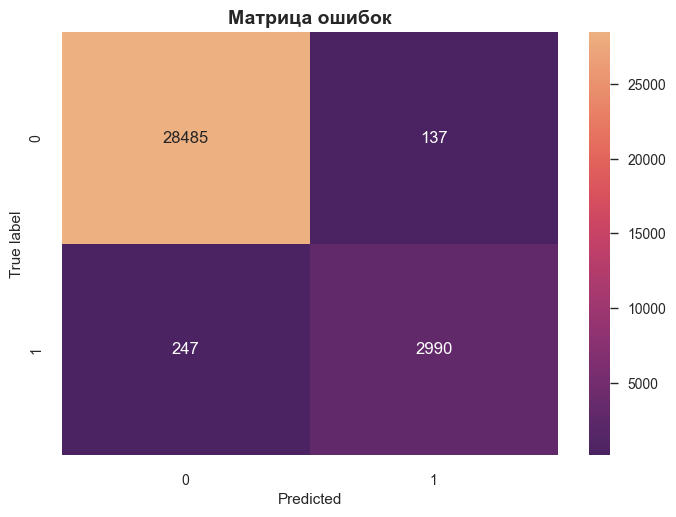

In [55]:
# вывод матрицы ошибок
print_confusion_matrix(label_test, test_predictions)

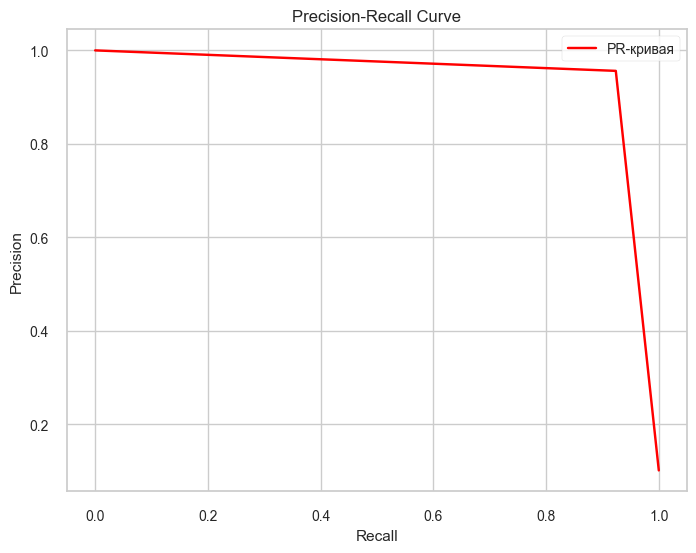

In [56]:
# посторение PR-кривой
# получаем данные для построения PR-кривой
precision, recall, _ = precision_recall_curve(label_test, test_predictions)
# визуализация PR-кривой
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', label="PR-кривая")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Выводы по проекту

### Главная задача проекта:

Создать модель для классификации комментариев на позитивные и негативные. Достичь значения метрики качества *F1* не меньше 0.75.

### Краткий обзор проделанной работы

1. Загружены данные.
2. Проведена их проверка на пропуски и дубликаты.
3. Проанализировано распределение целевой переменной.
4. Набор данных разделен на обучающую, тестовую и валидационную выборки.
5. Обучена модель логистической регрессии с различными вариантами кодирования текстов:

- __TF-IDF__
- __spaCy__
- __BERT embeddings__

6. Получены пронозы на предобученной модели __BERT (*unitary/toxic-bert*)__, которая показала лучший результат.
7. Проведено тестирование лучшей модели на тестовой выборке и анализ метрик исходя из задачи бизнеса.

### Оценка результатов в контексте бизнес-задачи

__Бизнес-цель__ – максимально выявлять токсичные комментарии, поэтому ключевая метрика – Recall (чтобы находить как можно больше токсичных сообщений).

Интерпретация метрик:

1. __F1-score = 0.940__ – общий баланс между точностью (Precision) и полнотой (Recall). Очень высокий показатель.

2. __Precision = 0.956__ – из всех комментариев, которые предсказаны как токсичные __95.6% действительно токсичны__. Это значит, что если модель говорит, что комментарий токсичен, то она ошибается в 4.4% случаев.

3. __Recall = 0.924__ – из всех реально токсичных комментариев модель "поймала" __92.4%__. Это означает, что модель пропускает 7.6% токсичных комментариев.
	
4. __Интерпретация матрицы ошибок:__

- TP (True Positive) — в 2990 случаях из 3237 модель правильно решила, что комментарий негативный.
- FP (False Positive) — в 247 из 3237 случаях модель ошибочно решила, что комментарий негативный.
- FN (False Negative) — в 137 случаях из 28622 модель ошибочно решила, что комментарий позитивный.
- TN (True Negative) — в 28485 случаях из 28622 модель правильно решила, что комментарий позитивный.

### Возможные улучшения

Увеличение Precision (уменьшение ложноположительных срабатываний):

- использование Threshold Tuning – подбор оптимального порога вероятности для предсказаний
- применение более сложных моделей (например, BERT с дообучением)